# 预习 2：神经网络架构地图 —— MLP / CNN / RNN / LSTM / GNN

> 建议学习顺序：预习 1 → 预习 2 → 预习 3 → 原 Day1 Attention。  
> 这份 notebook 的目标是让你知道 Transformer 不是突然出现的，它是在 MLP、CNN、RNN/LSTM 等架构之后，为了解决序列建模和长距离依赖问题而发展出来的。

---

## 这份 notebook 解决什么问题？

你提到希望补充：

- CNN
- RNN
- LSTM
- GNN
- 神经网络架构分类
- 深度学习模型有哪些

这份就是围绕这些内容展开。

## 核心问题

不同神经网络架构的本质差异，不是“名字不同”，而是：

> 它们对数据结构的归纳偏置不同。

| 数据结构 | 典型模型 | 归纳偏置 |
|---|---|---|
| 表格 / 普通向量 | MLP | 全连接特征组合 |
| 图像网格 | CNN | 局部性、平移等变 |
| 时间序列 / 文本序列 | RNN / LSTM | 顺序依赖、状态记忆 |
| 图结构 | GNN | 节点邻居消息传递 |
| 长文本 / 多模态序列 | Transformer | 全局 token-token 交互 |

# 0. 环境准备

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("ready")

ready


# 1. 神经网络的基本单元：Linear + Activation

一个最基本的神经网络层：

$$
h = \phi(xW + b)
$$

其中：

- $x$：输入
- $W$：权重矩阵
- $b$：偏置
- $\phi$：非线性激活函数
- $h$：输出表示

如果没有激活函数，多层线性层叠加仍然等价于一层线性层。  
所以非线性激活是神经网络表达复杂函数的关键。

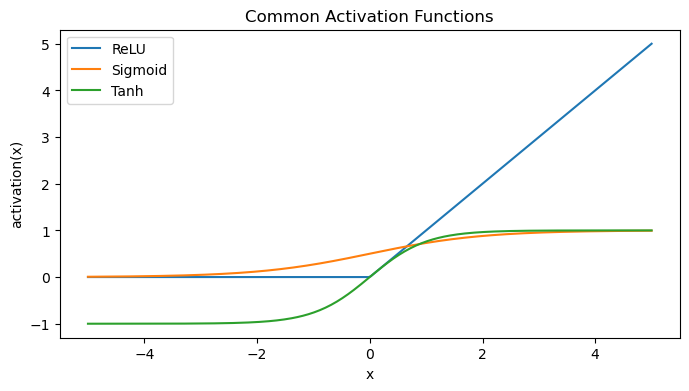

In [2]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

x = np.linspace(-5, 5, 300)

plt.figure(figsize=(8, 4))
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.title("Common Activation Functions")
plt.xlabel("x")
plt.ylabel("activation(x)")
plt.legend()
plt.show()

# 2. MLP：最基础的全连接神经网络

MLP，也叫多层感知机，是最普通的前馈网络：

```text
输入向量 -> Linear -> Activation -> Linear -> Activation -> 输出
```

适合：

- 表格数据
- 小规模特征分类
- 作为其他模型里的子模块

Transformer 里的 FFN / MLP 层，本质上就是一个 token-wise 的 MLP。

In [3]:
# 一个最小 MLP 前向传播
B = 4       # batch size
d_in = 5    # 输入维度
d_hidden = 8
d_out = 3   # 输出类别数

X = np.random.randn(B, d_in)
W1 = np.random.randn(d_in, d_hidden) * 0.1
b1 = np.zeros(d_hidden)
W2 = np.random.randn(d_hidden, d_out) * 0.1
b2 = np.zeros(d_out)

H = relu(X @ W1 + b1)
logits = H @ W2 + b2

print("X shape:", X.shape)
print("H shape:", H.shape)
print("logits shape:", logits.shape)

X shape: (4, 5)
H shape: (4, 8)
logits shape: (4, 3)


# 3. CNN：为什么适合图像？

图像有两个重要结构：

1. **局部性**：相邻像素关系更强
2. **平移等变性**：同一个边缘出现在左边或右边，本质上还是边缘

CNN 用卷积核在图像上滑动，共享同一组参数。  
这比 MLP 直接连接所有像素更高效。

## 卷积直觉

一个卷积核可以检测某种局部模式：

- 横向边缘
- 纵向边缘
- 纹理
- 角点
- 更高层的物体部件

多层 CNN 会逐渐形成：

```text
边缘 -> 纹理 -> 局部部件 -> 物体
```

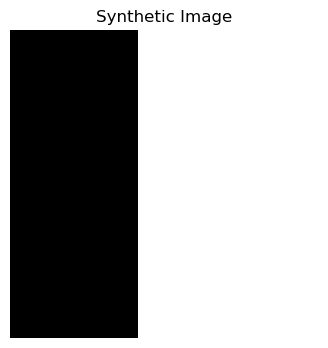

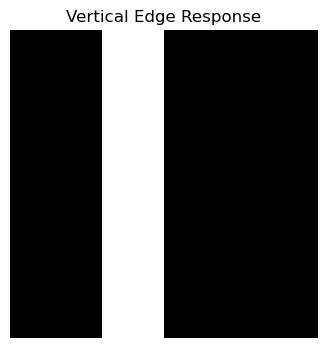

In [4]:
# 手写 2D 卷积，用一个简单图像观察边缘检测
def conv2d(image, kernel):
    H, W = image.shape
    kH, kW = kernel.shape
    out_H = H - kH + 1
    out_W = W - kW + 1
    out = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = image[i:i+kH, j:j+kW]
            out[i, j] = np.sum(patch * kernel)
    return out

image = np.zeros((12, 12))
image[:, 5:] = 1.0  # 人造一条垂直边界

vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

edge = conv2d(image, vertical_edge_kernel)

plt.figure(figsize=(5, 4))
plt.imshow(image, cmap="gray")
plt.title("Synthetic Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(edge, cmap="gray")
plt.title("Vertical Edge Response")
plt.axis("off")
plt.show()

# 4. CNN 关键概念：kernel / stride / padding / channel

## Kernel 卷积核

卷积核是一个小窗口，例如 $3 \times 3$。  
它在图像上滑动，检测局部模式。

## Stride 步长

stride 表示卷积核每次移动多少格。  
stride 越大，输出越小。

## Padding 填充

padding 在图像边缘补 0，防止尺寸缩小太快。

## Channel 通道

RGB 图像有 3 个通道。  
深层 CNN 的 feature map 可能有 64、128、256 个通道。  
每个通道可以理解为一种特征检测器。

# 5. RNN：为序列而生的神经网络

文本、语音、时间序列都有顺序结构。

RNN 的核心递推：

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

其中：

- $x_t$：当前时刻输入
- $h_{t-1}$：上一个时刻隐藏状态
- $h_t$：当前状态

RNN 的直觉：

> 用一个隐藏状态 $h_t$ 记住前面看过的信息。

## 问题

普通 RNN 很难记住很远的信息，因为梯度容易消失或爆炸。

In [5]:
# 一个最小 RNN 前向传播
T = 6
d_x = 3
d_h = 4

X_seq = np.random.randn(T, d_x)
Wx = np.random.randn(d_x, d_h) * 0.2
Wh = np.random.randn(d_h, d_h) * 0.2
b = np.zeros(d_h)

h = np.zeros(d_h)
states = []

for t in range(T):
    h = np.tanh(X_seq[t] @ Wx + h @ Wh + b)
    states.append(h.copy())

states = np.array(states)
print("sequence input shape:", X_seq.shape)
print("hidden states shape:", states.shape)
print(states)

sequence input shape: (6, 3)
hidden states shape: (6, 4)
[[-0.45036206  0.10694339  0.01126065  0.37403621]
 [-0.42067962 -0.12983016 -0.00288769  0.32783368]
 [ 0.49971354 -0.05918013  0.02687553 -0.25875926]
 [ 0.4318934   0.08941517 -0.04206738 -0.6695054 ]
 [ 0.19821441  0.08845827 -0.00317665 -0.04563141]
 [-0.32362007  0.02176544 -0.05900096 -0.25833984]]


# 6. LSTM：为了解决长期记忆问题

LSTM 是 RNN 的改进版，引入了门控机制。

核心思想：

> 不是什么都写进记忆，也不是什么都忘掉，而是让模型自己学会“保留、遗忘、输出”。

LSTM 有三个重要门：

| 门 | 作用 |
|---|---|
| forget gate | 决定旧记忆保留多少 |
| input gate | 决定新信息写入多少 |
| output gate | 决定输出多少记忆 |

简化公式：

$$
f_t = \sigma(W_f[x_t, h_{t-1}])
$$

$$
i_t = \sigma(W_i[x_t, h_{t-1}])
$$

$$
\tilde{c}_t = \tanh(W_c[x_t, h_{t-1}])
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
h_t = o_t \odot \tanh(c_t)
$$

In [6]:
# 一个简化 LSTM 单步示意
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

d_x, d_h = 3, 4
x_t = np.random.randn(d_x)
h_prev = np.random.randn(d_h)
c_prev = np.random.randn(d_h)

concat = np.concatenate([x_t, h_prev])
Wf = np.random.randn(d_x + d_h, d_h) * 0.2
Wi = np.random.randn(d_x + d_h, d_h) * 0.2
Wo = np.random.randn(d_x + d_h, d_h) * 0.2
Wc = np.random.randn(d_x + d_h, d_h) * 0.2

f = sigmoid(concat @ Wf)
i = sigmoid(concat @ Wi)
o = sigmoid(concat @ Wo)
c_tilde = np.tanh(concat @ Wc)

c = f * c_prev + i * c_tilde
h = o * np.tanh(c)

print("forget gate:", f)
print("input gate:", i)
print("output gate:", o)
print("new cell state:", c)
print("new hidden state:", h)

forget gate: [0.41494183 0.712088   0.29133653 0.68223548]
input gate: [0.36417192 0.49547353 0.48765912 0.55737858]
output gate: [0.65101579 0.43572311 0.62381493 0.68667805]
new cell state: [-0.24580143  0.31649513 -0.46522155  0.58273827]
new hidden state: [-0.15687391  0.13347697 -0.27094175  0.36026757]


# 7. GRU：比 LSTM 更简洁的门控 RNN

GRU 可以理解为 LSTM 的简化版：

- 参数更少
- 训练更快
- 很多任务上效果接近 LSTM

主要门：

| 门 | 作用 |
|---|---|
| update gate | 控制保留多少旧状态 |
| reset gate | 控制遗忘多少历史信息 |

在 Transformer 出现前，RNN/LSTM/GRU 是 NLP 的主流序列建模架构。

# 8. 为什么 RNN/LSTM 后来被 Transformer 大规模替代？

RNN 系列最大的问题：

## 8.1 串行计算

RNN 必须按顺序处理：

```text
x1 -> x2 -> x3 -> x4 -> ...
```

不能很好并行。

## 8.2 长距离依赖困难

虽然 LSTM 改善了长期记忆，但对很长文本仍然吃力。

## 8.3 信息瓶颈

所有历史信息被压进一个 hidden state，容易丢失细节。

Transformer 的 Attention 直接让每个 token 和其他 token 建立联系，因此更适合大规模并行训练和长文本建模。

# 9. GNN：图神经网络为什么存在？

有些数据不是表格、图像、序列，而是图结构：

- 社交网络
- 分子结构
- 知识图谱
- 推荐系统
- 交通网络
- 电网 / 储能网络

图由节点和边组成：

```text
node: 实体
edge: 实体之间的关系
```

GNN 的核心思想：

> 每个节点从邻居节点收集信息，更新自己的表示。

常见形式：

$$
h_v^{(k)} = \text{UPDATE}\left(h_v^{(k-1)}, \text{AGGREGATE}\{h_u^{(k-1)}: u \in \mathcal{N}(v)\}\right)
$$

In [7]:
# 一个最小 GNN message passing 示例
# 4 个节点，每个节点 3 维特征
X = np.array([
    [1.0, 0.0, 0.0],  # node 0
    [0.0, 1.0, 0.0],  # node 1
    [0.0, 0.0, 1.0],  # node 2
    [1.0, 1.0, 0.0],  # node 3
])

# 邻接矩阵：1 表示有边
A = np.array([
    [1, 1, 0, 0],  # node 0 connects self and node 1
    [1, 1, 1, 0],
    [0, 1, 1, 1],
    [0, 0, 1, 1],
], dtype=float)

# 简单归一化：每个节点取邻居平均
D = A.sum(axis=1, keepdims=True)
A_norm = A / D

H_next = A_norm @ X

print("Original node features:")
print(X)
print("\nAfter one message passing step:")
print(H_next)

Original node features:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 1. 0.]]

After one message passing step:
[[0.5        0.5        0.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.66666667 0.33333333]
 [0.5        0.5        0.5       ]]


# 10. Autoencoder / VAE / GAN / Diffusion：生成模型速览

除了分类和预测，深度学习还有生成任务。

## Autoencoder

把输入压缩成 latent，再重建输入。

```text
x -> encoder -> z -> decoder -> x'
```

常用于降维、去噪、表示学习。

## VAE

变分自编码器，让 latent space 更连续可采样。

## GAN

生成器和判别器对抗训练：

```text
Generator 造假
Discriminator 辨别真假
```

## Diffusion

从噪声逐步去噪生成图像。  
Stable Diffusion、SDXL、Flux 等图像生成模型都属于扩散模型路线。

## LLM

语言模型生成的是 token 序列，本质是自回归概率建模。

# 11. Transformer 的位置：不是所有模型的替代品，但它统一了很多任务

Transformer 最初为 NLP 提出，但后来扩展到：

- 文本：BERT、GPT、T5、Qwen、LLaMA
- 图像：ViT、Swin Transformer
- 多模态：CLIP、Flamingo、GPT-4o 类系统
- 语音：Whisper
- 生成图像：扩散模型里的 text encoder、DiT

为什么 Transformer 能扩展？

因为它把输入统一成 token 序列，然后用 Attention 建模 token 之间的关系。

# 12. 架构对比总表

| 架构 | 输入结构 | 核心操作 | 优点 | 缺点 |
|---|---|---|---|---|
| MLP | 向量 | 全连接 | 简单通用 | 不利用结构 |
| CNN | 图像网格 | 局部卷积 | 高效、适合视觉 | 长距离关系弱 |
| RNN | 序列 | 递归状态 | 能处理变长序列 | 难并行 |
| LSTM/GRU | 序列 | 门控记忆 | 改善长期依赖 | 仍然串行 |
| GNN | 图 | 邻居聚合 | 适合关系数据 | 大图训练复杂 |
| Transformer | token 序列 | Attention | 并行、全局交互 | 长序列成本高 |

# 13. 为什么你学习 LLM 前仍然需要知道 CNN/LSTM/GNN？

因为它们帮助你建立“架构为什么这样设计”的思维。

- CNN：告诉你什么是局部归纳偏置
- RNN/LSTM：告诉你早期序列建模的瓶颈
- GNN：告诉你 message passing 的思想
- Transformer：可以看成一种全局 message passing

你后面看 Attention 时可以这样理解：

> 每个 token 都是一个节点，Attention 权重就是 token 与 token 之间的动态边。

# 14. 面试/复习高频问题

## Q1：CNN 为什么比 MLP 更适合图像？

因为 CNN 利用局部连接和参数共享，减少参数量，并符合图像局部模式可平移复用的结构。

## Q2：RNN 为什么难以并行？

因为 $h_t$ 依赖 $h_{t-1}$，必须顺序计算。

## Q3：LSTM 解决了 RNN 的什么问题？

通过门控机制改善长期记忆和梯度消失问题。

## Q4：GNN 的核心是什么？

邻居消息传递和节点表示更新。

## Q5：Transformer 相比 RNN 的核心优势是什么？

它允许序列中任意 token 之间直接交互，并且训练阶段可以高度并行。

# 15. 自测题

1. MLP、CNN、RNN、GNN 分别适合什么数据结构？
2. CNN 的 kernel、stride、padding、channel 分别是什么？
3. RNN 的隐藏状态 $h_t$ 有什么作用？
4. LSTM 的三个门分别控制什么？
5. 为什么 RNN/LSTM 不适合大规模并行训练？
6. GNN 的 message passing 是什么？
7. Transformer 可以如何理解成“全局 message passing”？
8. Transformer 的主要代价是什么？
9. 为什么 CNN/LSTM 仍然值得学习？
10. 后面 Attention 里的 token-token 关系和图里的 node-node 关系有什么相似之处？

答完后进入“预习 3：NLP / CV / LLM 总览与 Transformer 前置概念”。